# 02 — Data Cleaning and Exploratory Analysis

**Phase 3** of the project plan, built up across several steps:

1. Cleaning policy — decided and documented in `reports/cleaning_policy.md` (no code here).
2. Cleaning implementation — `src/auto_pricing/features.py` + `scripts/prepare_data.py`, producing `data/processed/`.
3. **This section:** univariate exploratory analysis — exposure and claim-count distributions, and the portfolio-level annual claim frequency.
4. Frequency by rating factor (added in a later step).
5. Severity distribution and large-loss concentration (added in a later step).
6. Pure premium distribution and wrap-up (added in a later step).

This notebook loads the **cleaned** tables (`load_frequency_clean`, `load_severity_clean`), not the raw ones — by this point, Exposure is already capped at 1.0, ClaimNb at 4, and orphaned claims already excluded, per the documented policy.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from auto_pricing.data import load_frequency_clean, load_severity_clean
from auto_pricing.eda import exposure_weighted_frequency, naive_mean_frequency, zero_claim_share

FIGURES_DIR = Path("..") / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

freq = load_frequency_clean()
sev = load_severity_clean()

print("frequency (cleaned):", freq.shape)
print("severity (cleaned): ", sev.shape)

Matplotlib is building the font cache; this may take a moment.


frequency (cleaned): (678013, 12)
severity (cleaned):  (26444, 2)


## 1. Exposure distribution

Exposure is the fraction of a policy-year each policy was observed. It matters here for a specific reason: a lot of policies have short exposure, and short-exposure policies are exactly what makes the naive frequency calculation in Section 3 go wrong.

In [2]:
freq["Exposure"].describe()

count    678013.000000
mean          0.528545
std           0.364081
min           0.002732
25%           0.180000
50%           0.490000
75%           0.990000
max           1.000000
Name: Exposure, dtype: float64

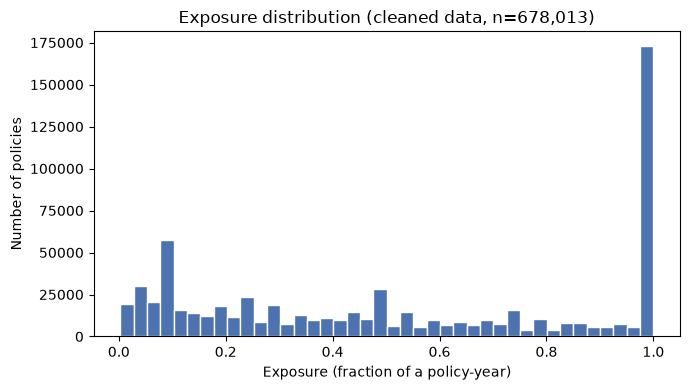

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(freq["Exposure"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Exposure (fraction of a policy-year)")
ax.set_ylabel("Number of policies")
ax.set_title("Exposure distribution (cleaned data, n=678,013)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "exposure_distribution.png", dpi=150)
plt.show()

The distribution is far from uniform: there's a spike near `Exposure = 1.0` (full-year policies, now including the 1,224 that were clipped down from above 1.0) and a long, fairly flat spread across shorter exposures. In other words, a meaningful share of the portfolio was only observed for a fraction of the year — exactly the situation Exposure exists to account for.

## 2. Claim count distribution and the zero-claim share

In [4]:
claim_counts = freq["ClaimNb"].value_counts().sort_index()
print(claim_counts)
print()
print(f"zero-claim share: {zero_claim_share(freq):.4%}")

ClaimNb
0    643953
1     32178
2      1784
3        82
4        16
Name: count, dtype: int64

zero-claim share: 94.9765%


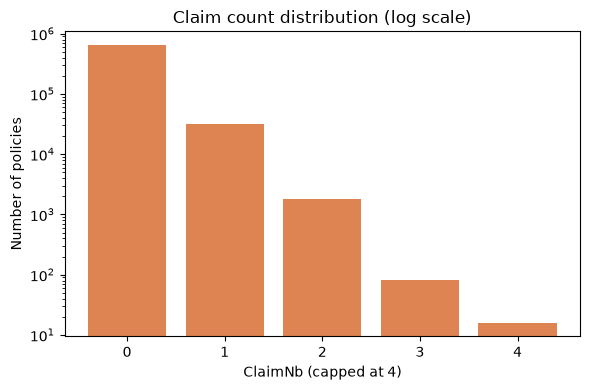

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(claim_counts.index.astype(str), claim_counts.values, color="#DD8452")
ax.set_xlabel("ClaimNb (capped at 4)")
ax.set_ylabel("Number of policies")
ax.set_yscale("log")
ax.set_title("Claim count distribution (log scale)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "claim_count_distribution.png", dpi=150)
plt.show()

**~95% of policies have zero claims.** This is the central challenge the whole modelling approach is built around: with claims this sparse, an ordinary regression on raw claim counts would be dominated by noise. It's also why the frequency model is evaluated on exposure-weighted deviance rather than plain accuracy — a model that predicts "zero claims for everyone" would already be right 95% of the time, and that is not a useful pricing model. (The log scale on the y-axis above is there so the 16 policies with `ClaimNb=4` remain visible at all next to the 643,953 with `ClaimNb=0`.)

## 3. Portfolio-level annual claim frequency — correct vs. naive

This is the calculation the project plan is explicit about getting right. The correct portfolio-level annual frequency is

$$\text{frequency} = \frac{\sum_i \text{ClaimNb}_i}{\sum_i \text{Exposure}_i}$$

**not** the plain average of each policy's own `ClaimNb / Exposure`. The two are computed side by side below on the real, cleaned data.

In [6]:
correct = exposure_weighted_frequency(freq)
naive = naive_mean_frequency(freq)

print(f"correct (exposure-weighted): {correct:.5f}  -> {correct*100:.2f} claims per 100 policy-years")
print(f"naive (mean of per-policy rates): {naive:.5f}  -> {naive*100:.2f} claims per 100 policy-years")
print(f"naive method overstates the true rate by {naive/correct:.1f}x")

correct (exposure-weighted): 0.10061  -> 10.06 claims per 100 policy-years
naive (mean of per-policy rates): 0.26350  -> 26.35 claims per 100 policy-years
naive method overstates the true rate by 2.6x


The naive method overstates the portfolio's true claim frequency by roughly **2.6×**. That is not a rounding difference — it would mean pricing every policy in the portfolio as if it were substantially riskier than it actually is. The next cell shows exactly why: a small number of policies with very little exposure but at least one claim produce absurd implied annual rates, and an unweighted average lets each of those count as much as any full-year policy.

In [7]:
tiny_exposure_claims = freq[(freq["Exposure"] < 0.01) & (freq["ClaimNb"] > 0)]
print(f"policies with Exposure < 0.01 years (~3.6 days) AND at least one claim: {len(tiny_exposure_claims)}")

example = tiny_exposure_claims.assign(implied_annual_rate=lambda d: d["ClaimNb"] / d["Exposure"])
example[["IDpol", "Exposure", "ClaimNb", "implied_annual_rate"]].sort_values(
    "implied_annual_rate", ascending=False
).head(5)

policies with Exposure < 0.01 years (~3.6 days) AND at least one claim: 152


,IDpol,Exposure,ClaimNb,implied_annual_rate
3360,7045,0.002732,2,732.0
4554,10019,0.002732,2,732.0
2838,5896,0.002732,2,732.0
716,1489,0.002732,1,366.0
1451,3003,0.002732,1,366.0


A policy exposed for about a day with two claims implies **732 claims per year** if you take its own rate at face value — obviously not a real annual claim rate, just a very small amount of exposure dividing a very small claim count. 152 such policies exist in the cleaned data, and averaging their per-policy rates alongside hundreds of thousands of full-year, zero-claim policies is what inflates the naive figure to 2.6× the truth.

The exposure-weighted formula avoids this because it never treats a claim in isolation from how much exposure produced it: it sums claims and sums exposure *separately*, across the whole group, before dividing. A tiny-exposure policy still contributes its one claim to the numerator, but only its tiny exposure to the denominator — it cannot dominate the result the way its own inflated per-policy rate would.

## 4. Summary

- Exposure is concentrated near 1.0 but spread widely below it — a large share of the portfolio has partial-year exposure.
- ~95% of policies have zero claims; frequency modelling has to work with genuinely sparse data.
- The portfolio's true annual claim frequency is **~10.06 claims per 100 policy-years** (exposure-weighted). The naive unweighted average would report **~26.35 per 100** — 2.6× too high — because it lets a small number of very-short-exposure policies with a claim dominate the result.

`exposure_weighted_frequency()` in `src/auto_pricing/eda.py` also accepts a `by=` argument for exactly this calculation at the segment level (e.g. by `Region` or `DrivAge` bucket), which is what the next step of this notebook uses.